In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.cluster import KMeans
from kneed import KneeLocator
from sklearn.metrics import silhouette_score

In [99]:
X,y = make_blobs(n_samples=1000, centers=3, n_features=2)
X,y

(array([[-4.4434029 , -4.82416103],
        [-3.82746752, -8.60819065],
        [ 7.28826528,  8.22061793],
        ...,
        [ 9.00300656,  8.94023211],
        [ 5.42516346, -9.17622636],
        [-3.37004511, -6.93997873]], shape=(1000, 2)),
 array([1, 1, 2, 2, 1, 2, 0, 2, 1, 1, 0, 2, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1,
        1, 1, 2, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 2, 2, 1, 2, 2, 0, 0, 1,
        0, 2, 1, 2, 2, 0, 0, 1, 0, 2, 1, 2, 1, 1, 2, 1, 0, 1, 0, 0, 1, 2,
        0, 0, 1, 0, 1, 0, 2, 0, 2, 1, 2, 1, 1, 0, 1, 0, 0, 2, 2, 0, 0, 0,
        2, 0, 2, 0, 1, 1, 0, 2, 2, 0, 2, 2, 0, 1, 1, 2, 2, 0, 2, 0, 2, 1,
        2, 2, 2, 2, 1, 0, 2, 0, 0, 2, 2, 2, 1, 2, 1, 1, 2, 1, 1, 2, 1, 1,
        2, 0, 1, 1, 1, 1, 2, 2, 1, 2, 2, 0, 2, 1, 2, 0, 1, 0, 2, 1, 1, 1,
        1, 2, 1, 2, 2, 0, 1, 0, 0, 0, 0, 0, 1, 2, 0, 2, 0, 2, 1, 2, 1, 2,
        0, 0, 1, 2, 0, 0, 2, 2, 2, 0, 0, 0, 0, 2, 2, 0, 2, 2, 2, 0, 1, 1,
        2, 2, 1, 0, 1, 0, 1, 1, 0, 0, 1, 2, 2, 2, 0, 0, 2, 0, 0, 0, 2, 1,
        1, 1

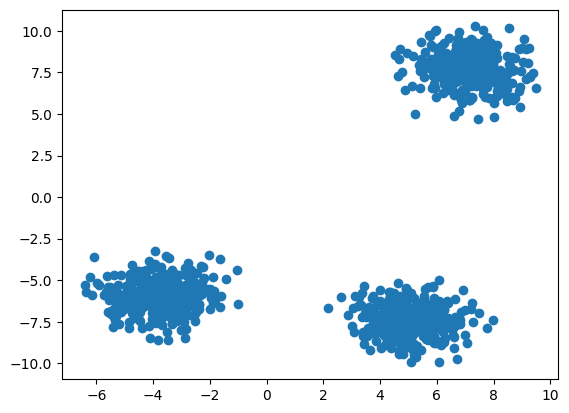

In [100]:
plt.scatter(X[:,0], X[:,1])

In [101]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [102]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [103]:
#Elbow mwthod to find optimal number of clusters
wcss = []
for k in range (1,15):
  kmeans = KMeans(n_clusters=k, init='k-means++')
  kmeans.fit(X_train_scaled)
  wcss.append(kmeans.inertia_)

In [104]:
wcss

[1600.000000000002,
 504.37236996163097,
 49.58280418590459,
 42.33283886273135,
 35.34884469666072,
 34.26310771174046,
 26.8412877457817,
 23.919163052974923,
 21.76032626031712,
 20.272063904063263,
 18.21246198025978,
 16.880173538079912,
 15.261510044474493,
 14.693558823904404]

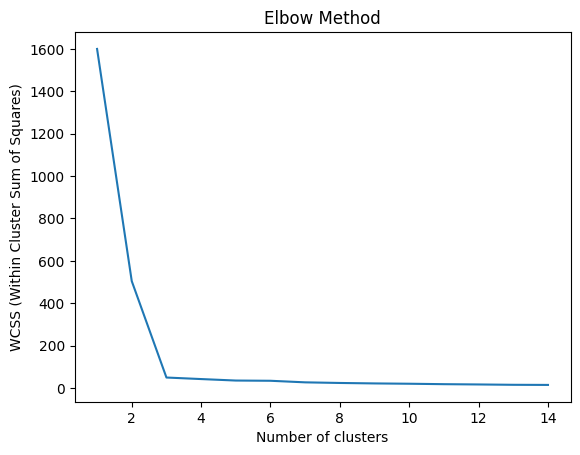

In [105]:
plt.plot(range(1,15), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS (Within Cluster Sum of Squares)')
plt.show()

In [106]:
kmeans.fit_predict(X_test_scaled)

array([10,  3,  6,  4, 13,  5,  4,  4,  4,  4,  3,  3,  4,  1,  2,  1,  9,
        7,  5,  1,  6,  8,  3, 12, 12,  6,  9,  9,  1,  5,  6,  0,  5,  5,
       13,  0, 12,  7,  0,  4,  4, 10,  8,  1,  9,  2,  7, 13,  9, 12, 10,
        3,  0, 10,  9,  2,  8,  7,  9,  2,  5,  1,  0,  3,  4,  1,  6,  5,
        9,  4, 13,  2,  3,  2,  9,  1,  7, 11,  0, 12,  7,  2,  7, 13,  9,
       12, 13,  6,  5,  2,  6, 11, 10, 12,  8,  1,  4, 10,  2,  6,  6,  5,
        7,  1, 10,  4,  6, 13, 13, 10,  8,  4,  8,  0,  5,  4,  6,  4,  1,
        2,  0,  7, 10, 12,  8,  0,  6, 10,  1,  4, 10,  7,  9,  9,  5, 10,
        0,  7,  4, 10,  2, 10,  6,  1,  2,  9,  2,  4,  3,  0, 12, 10, 13,
        0, 10,  1, 12,  9,  5,  2, 13,  9,  0,  0, 12,  5,  2,  7,  6,  1,
        5,  4,  0,  2,  1,  5,  5,  0,  2, 11,  4,  5,  0,  5,  4,  4,  4,
        8,  3,  0,  4,  7, 13, 10,  5,  5,  7,  1,  3,  1], dtype=int32)

In [107]:
kmeans = KMeans(n_clusters=3, init='k-means++')

In [108]:
y_pred = kmeans.fit_predict(X_test_scaled)
y_pred

array([1, 1, 1, 0, 2, 2, 0, 0, 0, 0, 1, 1, 0, 0, 2, 0, 0, 2, 2, 0, 1, 0,
       1, 1, 1, 1, 0, 0, 0, 2, 1, 1, 2, 2, 2, 1, 1, 2, 1, 0, 0, 1, 0, 0,
       0, 2, 2, 2, 0, 1, 1, 1, 1, 1, 0, 2, 0, 2, 0, 2, 2, 0, 1, 1, 0, 0,
       1, 2, 0, 0, 2, 2, 1, 2, 0, 0, 2, 1, 1, 1, 2, 2, 2, 2, 0, 1, 2, 1,
       2, 2, 1, 1, 1, 1, 0, 0, 0, 1, 2, 1, 1, 2, 2, 0, 1, 0, 1, 2, 2, 1,
       0, 0, 0, 1, 2, 0, 1, 0, 0, 2, 1, 2, 1, 1, 0, 1, 1, 1, 0, 0, 1, 2,
       0, 0, 2, 1, 1, 2, 0, 1, 2, 1, 1, 0, 2, 0, 2, 0, 1, 1, 1, 1, 2, 1,
       1, 0, 1, 0, 2, 2, 2, 0, 1, 1, 1, 2, 2, 2, 1, 0, 2, 0, 1, 2, 0, 2,
       2, 1, 2, 1, 0, 2, 1, 2, 0, 0, 0, 0, 1, 1, 0, 2, 2, 1, 2, 2, 2, 0,
       1, 0], dtype=int32)

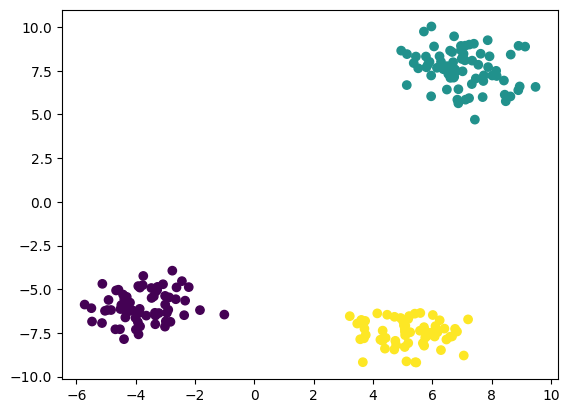

In [109]:
plt.scatter(X_test[:,0], X_test[:,1], c=y_pred)

In [110]:
knee = KneeLocator(range(1,15), wcss, curve='convex', direction='decreasing')

In [111]:
print(f'Optimal number of clusters: {knee.knee}')

Optimal number of clusters: 3


In [112]:
#Silhouette score
silhouette_coefficient = []

for k in range(2,15):
  kmeans = KMeans(n_clusters=k, init='k-means++')
  kmeans.fit(X_train_scaled)
  score = silhouette_score(X_train_scaled,kmeans.labels_ )
  silhouette_coefficient.append(score)

In [113]:
print(f'Silhouette scores: {silhouette_coefficient}')

Silhouette scores: [0.6805252716074753, 0.8398214772487441, 0.6726885762209096, 0.524757244783903, 0.35937817057419363, 0.3431585976531788, 0.3362587372704962, 0.34446553258549445, 0.31347357486114824, 0.3308562426430385, 0.33153074421801476, 0.332533944434672, 0.3274898021136815]


Text(0, 0.5, 'Silhouette Score')

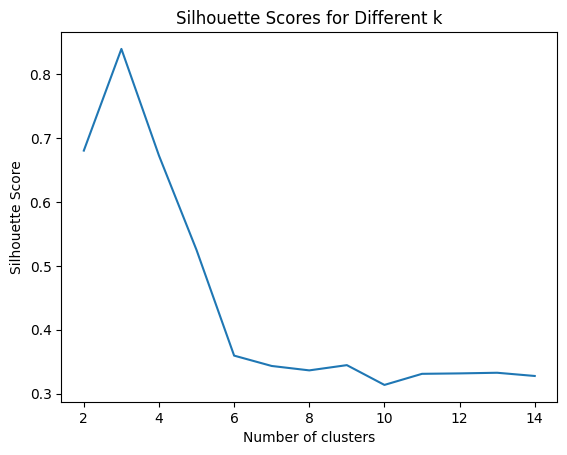

In [114]:
plt.plot(range(2,15), silhouette_coefficient)
plt.title('Silhouette Scores for Different k')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')